In [ ]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
timestamp = time()

In [3]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return O, operator_list

In [182]:
###### Model parameters
#Length of chain
L = 10
#X fields
J1 = 1 #NN term 
h0 = 0.9
#Basis being projected
op = "x"

In [ ]:
###Using Quantum_Operator to build hamitlonian 
timestamp = time()
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
#site coupling lists
sigma_z = [ [1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
##########################################################################################
basis = spin_basis_1d(L, pauli = -1,pblock = 1)
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False);
#Define Parameters########################################################################


In [244]:
params_dict = dict( H0=1, Quench=0.8)
#Build H0
H0 = H.tohamiltonian(params_dict)
#Find eigenvalues
E1,V1 = np.linalg.eigh(H0.todense())
V1 = np.array(V1)
#
params_dict = dict( H0=1, Quench=100)
#Build H0
H0 = H.tohamiltonian(params_dict)
E2,V2 = np.linalg.eigh(H0.todense())
V2 = np.array(V2)

In [245]:
for n in range(1,10):
    Opsi = np.array((fin_string(int(n),"x")[0]).todense())

    print(np.conj(V1[:,0].T)@Opsi@V1[:,0] - np.conj(V2[:,0].T)@Opsi@V2[:,0] )

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/1715388564.py:4: RuntimeWarning: divide by zero encountered in matmul
  print(np.conj(V1[:,0].T)@Opsi@V1[:,0] - np.conj(V2[:,0].T)@Opsi@V2[:,0] )
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/1715388564.py:4: RuntimeWarning: overflow encountered in matmul
  print(np.conj(V1[:,0].T)@Opsi@V1[:,0] - np.conj(V2[:,0].T)@Opsi@V2[:,0] )
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/1715388564.py:4: RuntimeWarning: invalid value encountered in matmul
  print(np.conj(V1[:,0].T)@Opsi@V1[:,0] - np.conj(V2[:,0].T)@Opsi@V2[:,0] )


(5.551115123125783e-16+0j)
(0.1995049802620587+0j)
(0.2960700052612948+0j)
(0.3353114675331881+0j)
(0.3456013131805894+0j)
(0.3417861543107669+0j)
(0.33142768189006266+0j)
(0.3183884041912034+0j)
(0.3048075298937231+0j)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/877752663.py:4: RuntimeWarning: divide by zero encountered in matmul
  dat2+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/877752663.py:4: RuntimeWarning: overflow encountered in matmul
  dat2+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/877752663.py:4: RuntimeWarning: invalid value encountered in matmul
  dat2+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]


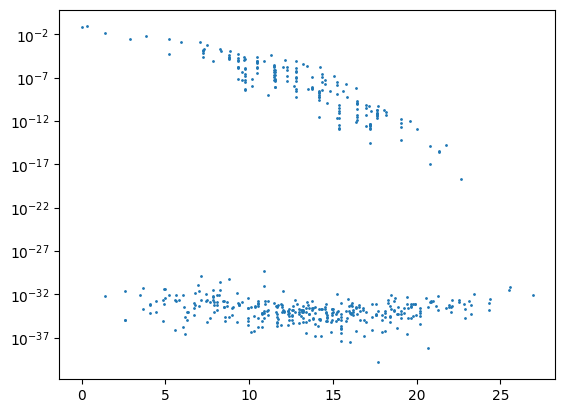

In [160]:
Opsi = np.array((fin_string(4,"x")[0]).todense())
dat2 = []
for n in range(len(E)):
    dat2+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]

plt.scatter(E-E[0],dat2,s=1)
plt.yscale("log")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/2974187559.py:4: RuntimeWarning: divide by zero encountered in matmul
  dat3+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/2974187559.py:4: RuntimeWarning: overflow encountered in matmul
  dat3+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49980/2974187559.py:4: RuntimeWarning: invalid value encountered in matmul
  dat3+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]


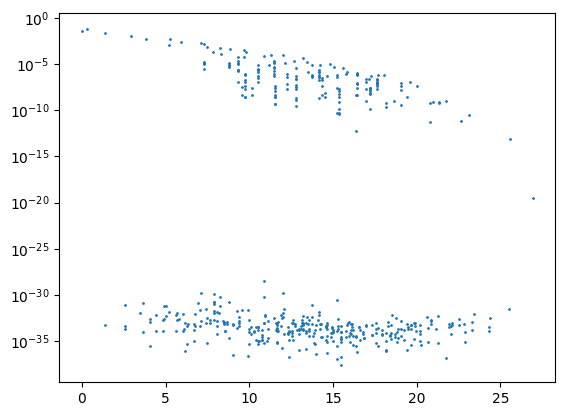

In [161]:
Opsi = np.array((fin_string(6,"x")[0]).todense())
dat3 = []
for n in range(len(E)):
    dat3+= [(np.conj(V[:,n].T)@Opsi@V[:,0])**2]

plt.scatter(E-E[0],dat3,s=1)
plt.yscale("log")

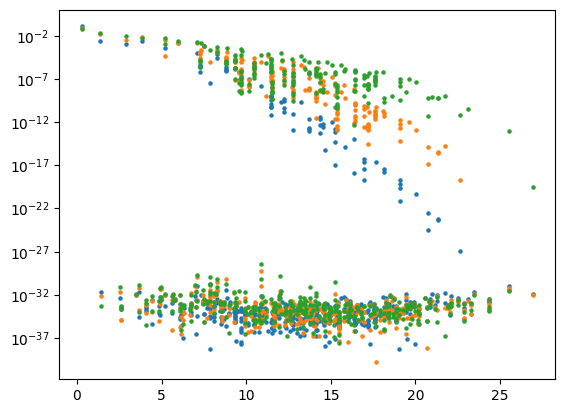

In [163]:
plt.scatter((E-E[0])[1:],dat[1:],s=5)
plt.scatter((E-E[0])[1:],dat2[1:],s=5)
plt.scatter((E-E[0])[1:],dat3[1:],s=5)
#plt.scatter(E-E[0],dat5,s=1)
plt.yscale("log")
#plt.ylim(0.000001,1)
